# Profiling Visualizations

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

CSV_PATH = "profiling_results_20260403_152951.csv"

df = pd.read_csv(CSV_PATH)

# Shared palette: MCP = blue, Text2SQL = coral/orange
PALETTE = {"mcp": "#185FA5", "text2sql": "#D85A30"}

# Global aesthetics
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 120

print(f"Loaded {len(df)} rows — modes: {df['mode'].value_counts().to_dict()}")

Loaded 52 rows — modes: {'mcp': 26, 'text2sql': 26}


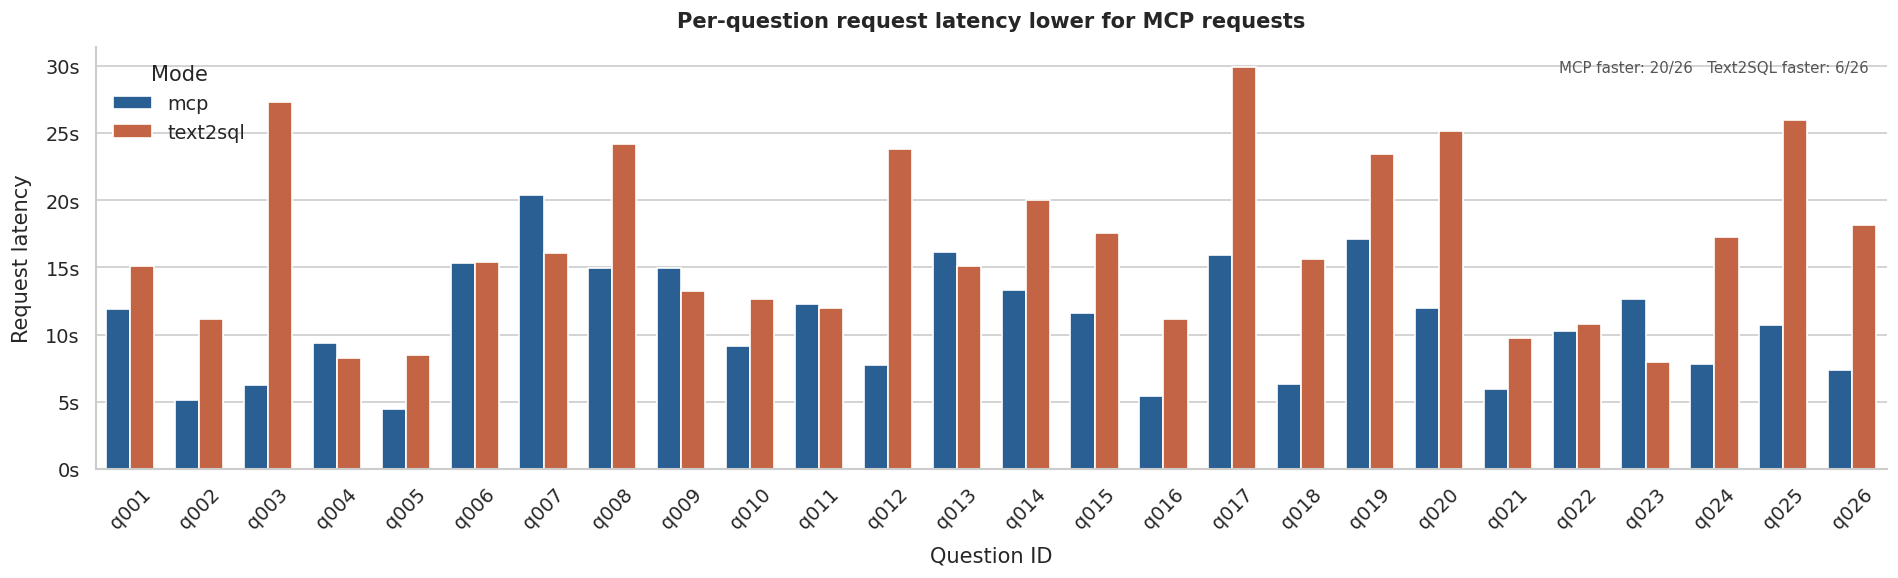

In [5]:
pivot = (
    df.pivot_table(index="question_id", columns="mode", values="client_request_latency_ms")
    .reset_index()
    .sort_values("question_id")
)

# Melt back to long form for seaborn
long = pivot.melt(id_vars="question_id", var_name="mode", value_name="latency_ms")

fig, ax = plt.subplots(figsize=(16, 5))

sns.barplot(
    data=long,
    x="question_id",
    y="latency_ms",
    hue="mode",
    palette=PALETTE,
    width=0.7,
    ax=ax,
)

# Y-axis in seconds
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}s"))
ax.set_xlabel("Question ID", labelpad=8)
ax.set_ylabel("Request latency", labelpad=8)
ax.set_title("Per-question request latency lower for MCP requests", fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45)

# Annotate which mode won for each question
mcp_faster = (pivot["mcp"] < pivot["text2sql"]).sum()
ax.text(
    0.99, 0.97,
    f"MCP faster: {mcp_faster}/26   Text2SQL faster: {26-mcp_faster}/26",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=9, color="#555",
)

ax.legend(title="Mode", frameon=False)
plt.tight_layout()
plt.show()

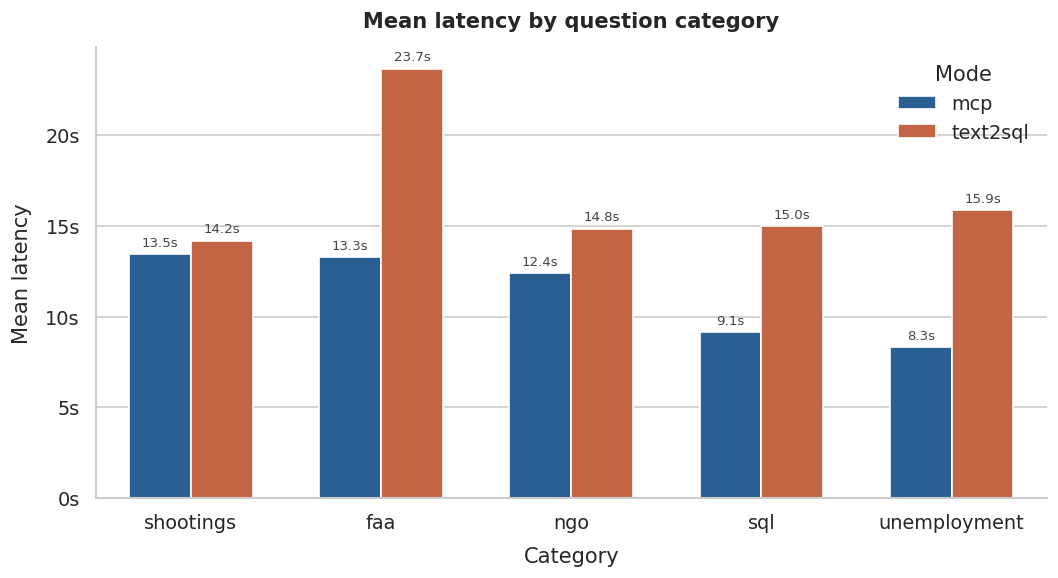

In [7]:
cat_means = (
    df.groupby(["mode", "category"])["client_request_latency_ms"]
    .mean()
    .reset_index()
)

# Category order by descending MCP latency for readability
order = (
    cat_means[cat_means["mode"] == "mcp"]
    .sort_values("client_request_latency_ms", ascending=False)["category"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=cat_means,
    x="category",
    y="client_request_latency_ms",
    hue="mode",
    palette=PALETTE,
    order=order,
    width=0.65,
    ax=ax,
)

# Add value labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda v: f"{v/1000:.1f}s",
        padding=3,
        fontsize=8,
        color="#444",
    )

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}s"))
ax.set_xlabel("Category", labelpad=8)
ax.set_ylabel("Mean latency", labelpad=8)
ax.set_title("Mean latency by question category", fontweight="bold", pad=12)
ax.legend(title="Mode", frameon=False)
plt.tight_layout()
plt.show()

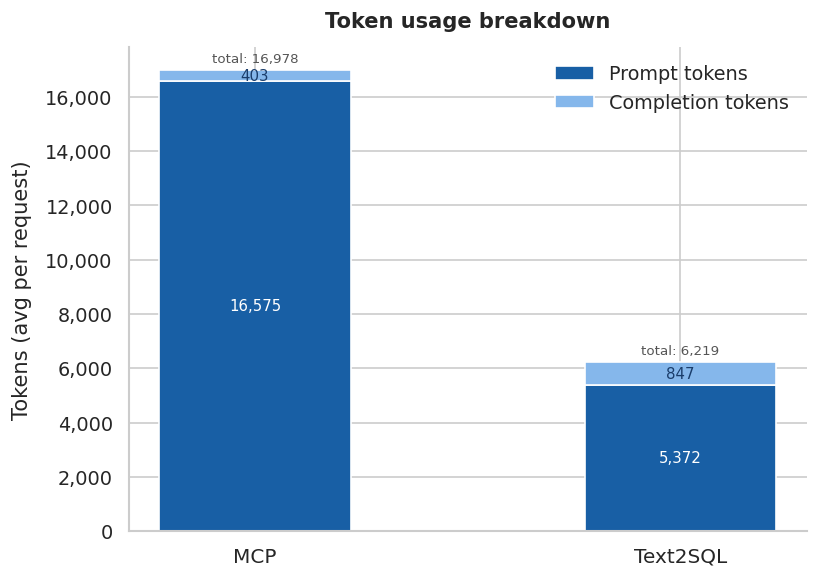

In [10]:
token_means = (
    df.groupby("mode")[["prompt_tokens", "completion_tokens"]]
    .mean()
    .reset_index()
)

# Consistent mode order
token_means["mode"] = pd.Categorical(token_means["mode"], categories=["mcp", "text2sql"])
token_means = token_means.sort_values("mode")

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(token_means))
w = 0.45

prompt_bars = ax.bar(
    x, token_means["prompt_tokens"], width=w,
    color="#185FA5", label="Prompt tokens"
)
completion_bars = ax.bar(
    x, token_means["completion_tokens"],
    bottom=token_means["prompt_tokens"], width=w,
    color="#85B7EB", label="Completion tokens"
)

# Annotate segment values
for i, row in token_means.iterrows():
    idx = list(token_means.index).index(i)
    # prompt label (inside bar)
    ax.text(idx, row["prompt_tokens"] / 2,
            f"{row['prompt_tokens']:,.0f}",
            ha="center", va="center", fontsize=9, color="white")
    # completion label (inside bar)
    ax.text(idx, row["prompt_tokens"] + row["completion_tokens"] / 2,
            f"{row['completion_tokens']:,.0f}",
            ha="center", va="center", fontsize=9, color="#1a3d6b")
    # total above bar
    total = row["prompt_tokens"] + row["completion_tokens"]
    ax.text(idx, total + 200, f"total: {total:,.0f}",
            ha="center", va="bottom", fontsize=8, color="#555")

ax.set_xticks(x)
ax.set_xticklabels(["MCP", "Text2SQL"], fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylabel("Tokens (avg per request)", labelpad=8)
ax.set_title("Token usage breakdown", fontweight="bold", pad=12)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()